In [2]:
#expected_return
import sys
sys.path.append('..')

from risk_engine.data_loader import get_market_data
import pandas as pd
import numpy as np

tickers = ['SPY', 'TLT', 'GLD']
prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

expected_return = returns.mean() * 252

print(f"expected_return: {expected_return}")

[*********************100%***********************]  3 of 3 completed

expected_return: Ticker
GLD    0.116334
SPY    0.155639
TLT   -0.048568
dtype: float64


In [12]:
#volatility

import numpy as np

volatility = returns.std() * np.sqrt(252)

print(f"annualized volatility: {volatility}")



annualized volatility: Ticker
GLD    0.155251
SPY    0.209973
TLT    0.179638
dtype: float64


In [1]:
import sys
sys.path.append('..')

from risk_engine.data_loader import get_market_data

from risk_engine.risk_metrics import volatility

tickers = ['SPY', 'TLT', 'GLD']
prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

print(volatility(returns))


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed

Ticker
GLD    0.155251
SPY    0.209973
TLT    0.179638
dtype: float64


In [103]:
#Var (Value at Risk)

# Although a negative #, its formatted in a way of Var = X% loss. 

def hist_var(asset_returns, confidence_level=0.95):
    var = asset_returns.quantile(1-confidence_level)
    return (var)

print(hist_var(asset_returns=returns))


Ticker
GLD   -0.015887
SPY   -0.019253
TLT   -0.017264
Name: 0.050000000000000044, dtype: float64


In [102]:
# CVaR (Conditional VaR)

def cvar(asset_returns, confidence_level=0.95):
    var_threshold = hist_var(asset_returns, confidence_level)
    bad_returns = asset_returns[asset_returns < var_threshold]
    return bad_returns.mean()

print(cvar(asset_returns=returns))

Ticker
GLD   -0.022800
SPY   -0.031952
TLT   -0.023830
dtype: float64


In [ ]:
# Correlation Matrix

def correlation_matrix(asset_returns):
    return asset_returns.corr()

print(correlation_matrix(returns))




Ticker       GLD       SPY       TLT
Ticker                              
GLD     1.000000  0.157949  0.266153
SPY     0.157949  1.000000 -0.150094
TLT     0.266153 -0.150094  1.000000


In [33]:
# Beta


def beta(asset_returns, market_returns):

    covariance = asset_returns.cov(market_returns)
    m_var = market_returns.var()
    return covariance / m_var

print(beta(returns['TLT'], returns['SPY']))








-0.1284101053074582


In [ ]:
# portfolio expected return

from risk_engine.risk_metrics import expected_return

def portfolio_expected_return(asset_returns, weights):

    individual_returns = expected_return(asset_returns)
    portfolio_returns = (individual_returns * weights).sum()
    return portfolio_returns

weights = np.array([0.33, 0.33, 0.34])

print(portfolio_expected_return(returns, weights))




0.07323788146689078


In [ ]:
# portfolio volatility


def portfolio_vol(asset_returns, weights):
    cov_matrix = asset_returns.cov() * 252
    return np.sqrt(weights.T @ cov_matrix @ weights)

weights = np.array([0.33, 0.33, 0.34])

print(portfolio_vol(returns, weights))



0.11257484006165117


[*********************100%***********************]  4 of 4 completed


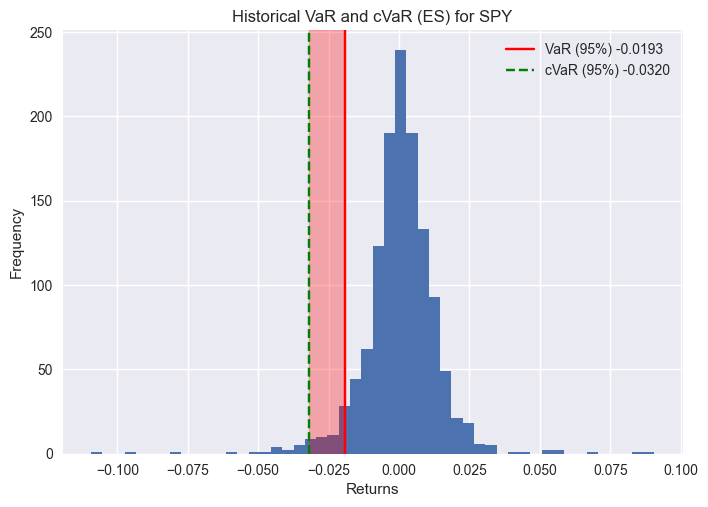

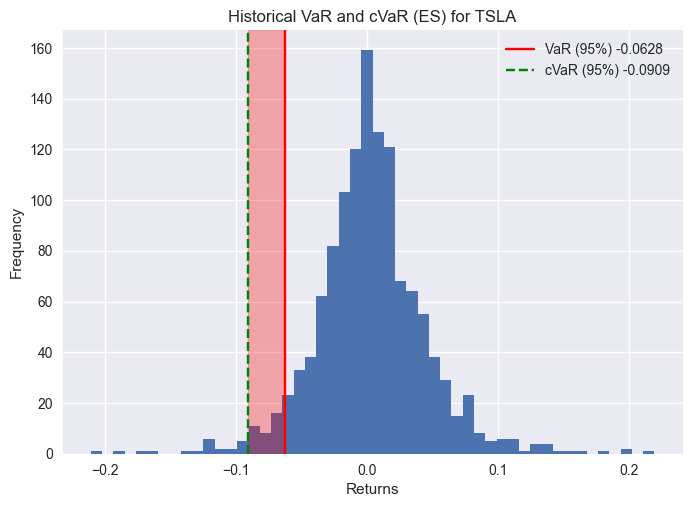

In [2]:
#Visualization
import sys
sys.path.append('..')

from risk_engine.data_loader import get_market_data

import matplotlib.pyplot as plt

from risk_engine.risk_metrics import hist_var, cvar

tickers = ['SPY', 'TLT', 'GLD', 'TSLA']
prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

def visualization(returns, var, cvar):
    plt.style.use('seaborn-v0_8')
    plt.hist(returns, bins=50)
    plt.axvline(var, color='red', label=f'VaR (95%) {var:.4f}')
    plt.axvline(cvar, color='green', linestyle='dashed', label=f'cVaR (95%) {cvar:.4f}')
    plt.axvspan(xmin=cvar, xmax=var, color='red', alpha=0.3)
    plt.title(f'Historical VaR and cVaR (ES) for {returns.name}')
    plt.xlabel('Returns')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
  

var = hist_var(returns['SPY'])
spy_cvar = cvar(returns['SPY'])

tsla_var = hist_var(returns['TSLA'])
tsla_cvar = cvar(returns['TSLA'])



visualization(returns=returns['SPY'], var=var, cvar=spy_cvar)
visualization(returns=returns['TSLA'], var=tsla_var, cvar=tsla_cvar)



In [1]:
#Portfolio VaR & cVaR
import sys
sys.path.append('..')


#portfolio_returns
def portfolio_returns(asset_returns, weights):
    return (asset_returns * weights).sum(axis=1)

import numpy as np
from risk_engine.data_loader import get_market_data
from risk_engine.risk_metrics import hist_var, cvar


tickers = ['SPY', 'TLT', 'GLD', 'TSLA']
weights = np.array([0.4, 0.2, 0.2, 0.1, 0.2])

prices, returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

#Portfolio VaR
def portfolio_var(asset_returns, weights):
    return hist_var(portfolio_returns(asset_returns, weights))

#Portfolio cVaR

def portfolio_cvar(asset_returns, weights):
    return cvar(portfolio_returns(asset_returns, weights))


print(portfolio_var(asset_returns=returns, weights=weights))
print(portfolio_cvar(asset_returns=returns, weights=weights))





[*********************100%***********************]  4 of 4 completed


ValueError: Unable to coerce to Series, length must be 4: given 5

In [ ]:
import sys
sys.path.append('..')

from risk_engine.data_loader import get_market_data
from risk_engine.risk_metrics import hist_var, cvar


tickers = ['SPY', 'TLT', 'GLD', 'TSLA']

price, asset_returns = get_market_data(tickers, '2020-01-01', '2025-01-01')

def stress_test(returns, start_date, end_date, confidence_level=0.95):
    
    crisis_period = returns.loc[start_date:end_date] #splice data
    
    return hist_var(crisis_period, confidence_level), cvar(crisis_period, confidence_level) 

print(stress_test(returns=asset_returns, start_date='2020-02-01', end_date='2020-03-31'))

print(cvar(asset_returns=asset_returns))



[*********************100%***********************]  4 of 4 completed


TypeError: stress_test() missing 1 required positional argument: 'confidence_level'